# Spacecraft Inspection Problem (3D, LVLH)

This notebook is a public companion for the 3-D inspection problem in:

Meta-Reinforcement Learning for Robust and Non-greedy Control Barrier Functions in Spacecraft Proximity Operations (TAES submission). 

It covers:
- Problem definition and parameters (as used in the paper)
- Loading a **fixed Monte Carlo episode bank**
- Evaluating three controllers on the same episode set:
    1. **Untuned ICCBF**
    2. **MLP-tuned ICCBF**
    3. **RNN (LSTM) tuned ICCBF**
- Producing metrics and plots (thrust distributions, success rates, etc.)

<p align="center">
  <img src="images/inspection.drawio.png" alt="Inspection Problem" width="55%"/>
</p>

*Figure: Inspection problem setup. $\alpha_{\mathrm{FOV}}$ denotes the field of view of the deputy's sensor, while $\theta_b$ is the angle between the sensor boresight and the Sun.*


## Problem Dynamics

The inspection problem is formulated in the chief-centred Hill (LVLH) reference frame. The origin is fixed at the centre of mass of the chief spacecraft, with unit vectors aligned such that $\hat{x}$ points radially outward from the Earth, $\hat{y}$ is aligned with the chief’s velocity direction, and $\hat{z}$ completes the right-handed triad. The chief is assumed to be on a circular orbit and remains stationary in this frame.

### Relative Translational Dynamics

The relative translational motion of the deputy spacecraft with respect to the chief is modelled using the Clohessy--Wiltshire (Hill) equations. Let the state vector be
$x = [x\; y\; z\; \dot{x}\; \dot{y}\; \dot{z}]^\top \in \mathbb{R}^6$,
where $(x,y,z)$ and $(\dot{x},\dot{y},\dot{z})$ denote the relative position and velocity in the Hill frame. The continuous-time dynamics are given by

\begin{equation}
\begin{aligned}
\ddot{x} - 2n\dot{y} - 3n^2 x &= \frac{F_x}{m},\\
\ddot{y} + 2n\dot{x} &= \frac{F_y}{m},\\
\ddot{z} + n^2 z &= \frac{F_z}{m}.
\end{aligned}
\end{equation}

where $n$ is the mean motion of the chief’s orbit, $m$ is the deputy mass, and $u = [F_x\; F_y\; F_z]^\top$ is the applied control force subject to component-wise saturation $|F_i| \le u_{\max}$.

These dynamics are discretised exactly under a zero-order hold assumption on the control input. With sampling time $\Delta t$, the discrete-time system evolves as
$x_{k+1} = A(\Delta t)x_k + B(\Delta t)u_k$,
where the matrices $A(\Delta t)$ and $B(\Delta t)$ correspond to the standard closed-form discretisation of the Clohessy--Wiltshire equations. 


### Sun Angle Evolution

The sun is modelled as a single distant light source that lies in the $\hat{x}$--$\hat{y}$ plane of the Hill frame. Its direction relative to the chief is parameterised by a scalar angle $\theta_S$, defining the unit vector
$r^S = [\cos\theta_S\; \sin\theta_S\; 0]^\top$.

As the chief progresses along its circular orbit, the apparent sun direction rotates in the Hill frame with angular rate equal to the mean motion. Accordingly, the sun angle evolves as
$\theta_{S,k+1} = \theta_{S,k} - n\Delta t$.

## Observation Model


### Perception Cone: In-View Condition

To determine which surface points are viewable by the deputy, a perception cone is defined over the discretized chief surface. Given a point $p_s$ on the chief sphere and the deputy position $p_d$, the point is inspectable (in view) if and only if

\begin{equation}
\frac{p_d}{\lVert p_d\rVert}\cdot p_s
\ge
r_c\left(1 - \frac{\lVert p_d\rVert - r_c}{\lVert p_d\rVert}\right),
\end{equation}

where $r_c$ is the chief radius. 
For this formulation, it is assumed that the sensor boresight always points toward the chief centre. 
Only points that satisfy the above Eq. are evaluated for illumination.

### Illumination and Inspection via Blinn--Phong

Illumination is incorporated using a two-step procedure motivated by backward ray tracing. First, points within the perception cone are checked for the possibility of illumination (unobstructed rays to the sun). Second, the Blinn--Phong reflectance model is used to compute the RGB illumination magnitude. 

For a surface point $p_s$, the Blinn--Phong RGB illumination is

\begin{equation}
I_p
=
k_a i_a
+
\sum_{l=1}^{l_{\max}}
k_d(\hat L^l\cdot \hat N)i_{l,d}
+
k_s(\hat N\cdot \hat H)^{\beta} i_{l,s},
\end{equation}


where $I_p$ is a $1\times 3$ RGB vector, $i_a$ is the ambient light, $i_{l,d}$ and $i_{l,s}$ are the diffuse and specular components of light source $l$, and $k_a$, $k_d$, and $k_s$ are the chief surface ambient, diffuse, and specular reflection constants, with shininess $\beta$. 

In this problem $l_{\max}=1$ since the only light source is the sun. 
Here $\hat N$ is the surface normal, $\hat V$ is the unit vector to the sensor, $\hat L$ is the unit vector to the light source, and the halfway vector is

\begin{equation}
\hat H
=
\frac{\hat L + \hat V}{\lVert \hat L + \hat V\rVert}
\end{equation}

Shadows of the deputy on the chief are not considered in this illumination analysis.
After computing $I_p$, an ad hoc thresholding criterion is applied: excessively bright or excessively dark illumination data are considered not useful and the corresponding points are not counted as inspected. 


This model is adapted from the paper "Safe Spacecraft Inspection via Deep Reinforcement Learning
and Discrete Control Barrier Functions" by David van Wijk et al. (DOI: https://arc.aiaa.org/doi/10.2514/1.I011391)

## Initial State \& Parameter Distribution

The deputy state is $(x=[r^\top,\,v^\top]^\top\in\mathbb{R}^6)$, where $r=[x\ y\ z]^\top$ and $v=[\dot x\ \dot y\ \dot z]^\top$ are expressed in the chief-centred LVLH frame. Relative motion is modelled with the Clohessy--Wiltshire (Hill) equations and control is a three-axis force input $u\in\mathbb{R}^3$ under ZOH with per-axis saturation $\lVert u\rVert_\infty \le u_{\max}$. 


Episodes are initialized by sampling the initial range $\lVert r_0\rVert\in[50,100]~\mathrm{m}$ with random azimuth and elevation, with $v_0=\mathbf{0}$. A sun-angle parameter $\theta_S\in[0,2\pi]$ defines the sun-direction unit vector $\hat r^S(\theta_S)$ in the Hill x-y plane.

The episode parameter vector for the inspection problem is $p_3 = [m_c,\ R_D,\ R_C,\ u_{\max},\ r,\ R_{\max}]^\top$
where $R_C$ is the chief radius, $R_D$ the deputy collision radius, and $R_{\max}$ the keep-in range. 

Parameters are sampled independently from a uniform distribution with bounds
\begin{align}
p_{\min} &= [9.6~\mathrm{kg},\ 4~\mathrm{m},\ 8~\mathrm{m},\ 0.8~\mathrm{N},\ 6093.9~\mathrm{km},\ 640~\mathrm{m}]^\top,\\
p_{\max} &= [14.4~\mathrm{kg},\ 6~\mathrm{m},\ 12~\mathrm{m},\ 1.2~\mathrm{N},\ 7448.1~\mathrm{km},\ 960~\mathrm{m}]^\top.
\end{align}


## Path Setup

In [3]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[0]   # notebooks/ -> repo root
SRC = REPO_ROOT / "src"
sys.path.insert(0, str(SRC))  # do this once per kernel

print("REPO_ROOT:", REPO_ROOT)
print("SRC:", SRC)

REPO_ROOT: /Users/minduli/CBF_journal/CBF_Public
SRC: /Users/minduli/CBF_journal/CBF_Public/src


In [ ]:
# Generate initial state distribution for inspection episodes
from inspection.inspection_make_fixed_ics import make_inspection_episode_bank
make_inspection_episode_bank()

In [ ]:
# Plot parameter distributions from the episode bank (edit keys as needed).
import numpy as np
import matplotlib.pyplot as plt

npz_path = "../src/data/inspection/inspection_episode_bank.npz"
D = np.load(npz_path, allow_pickle=True)
print("Keys:", D.files)

# Expected (example) keys; adjust to your saved names.
keys = ["m_vec", "R_D_vec", "R_C_vec", "U_MAX_vec", "r_vec", "R_MAX_vec"]

titles = {
    "m_vec": r"Mass $m_c$ [kg]",
    "R_D_vec": r"Deputy radius $R_D$ [m]",
    "R_C_vec": r"Chief radius $R_C$ [m]",
    "U_MAX_vec": r"Max thrust $u_{\max}$ [N]",
    "r_vec": r"Orbit radius $r$ [km]",
    "R_MAX_vec": r"Keep-in range $R_{\max}$ [m]",
}

fig, axes = plt.subplots(3, 2, figsize=(10, 7))
axes = axes.ravel()

for i, k in enumerate(keys):
    ax = axes[i]
    x = np.asarray(D[k]).astype(float)
    ax.hist(x, bins=60)
    ax.set_title(titles.get(k, k))
    ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

### Training (MLP / PPO)

In [ ]:
from inspection.inspection_train_DCNN import train_inspection

model, log_dir = train_inspection(
    dt=10.0,
    total_episodes=200_000,
    approx_episode_len=1224,
    seed=123,

    layers=4,
    nodes=256,
    activation_fn="tanh",
    policy_type="PPO",

    learning_rate=1e-4,
    lr_type="D",
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    n_epochs=10,
    batch_size=64,
    n_steps=400,

    num_env=1,
    trainON=True,
    trainLoad=False,

    init_da=True,
    da_order=4,
    da_vars=3,

    root_log_dir="TrainedModels",
)

print("Saved in:", log_dir)

### Training (RNN / RecurrentPPO)

In [ ]:
# Inspection RNN (RecurrentPPO) training template.
from inspection.inspection_train_DCNN import train_inspection

model, log_dir = train_inspection(
    dt=10.0,
    total_episodes=200_000,
    approx_episode_len=1224,
    seed=123,

    layers=4,
    nodes=256,
    activation_fn="tanh",
    policy_type="RNN",

    learning_rate=1e-4,
    lr_type="D",
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    n_epochs=10,
    batch_size=64,
    n_steps=400,

    lstm_hidden_size=256,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True,
    use_sde=False,

    num_env=1,
    trainON=True,
    trainLoad=False,

    init_da=True,
    da_order=4,
    da_vars=3,

    root_log_dir="TrainedModels",
)

print("Saved in:", log_dir)

In [ ]:

model, log_dir = train_inspection(
    dt=10.0,
    total_episodes=200_000,
    approx_episode_len=1224,
    seed=123,

    layers=4,
    nodes=256,
    activation_fn="tanh",
    policy_type="RNN",

    learning_rate=1e-4,
    lr_type="D",
    gamma=0.99,
    gae_lambda=0.95,
    clip_range=0.2,
    ent_coef=0.01,
    n_epochs=10,
    batch_size=64,
    n_steps=400,

    lstm_hidden_size=256,
    n_lstm_layers=1,
    shared_lstm=False,
    enable_critic_lstm=True,
    use_sde=False,

    num_env=1,
    trainON=True,
    trainLoad=False,

    init_da=True,
    da_order=4,
    da_vars=3,

    root_log_dir="TrainedModels",
)

print("Saved in:", log_dir)

### Evaluation

In [ ]:
# Parallel evaluation template (mirrors docking.eval_parallel_docking)
# Update module + config fields to match your inspection evaluator.

from inspection.eval_parallel_inspection import EvalConfig, evaluate_parallel

## MLP
cfg = EvalConfig(
    ics_path=str("../src/data/inspection/inspection_episode_bank.npz"),
    model_path=str("../src/inspection/TrainedModels/PPO_2/best_model.zip"),
    algo="PPO",
    dt=10.0,
    TOF=3.4*3600,      # ~3.4 h max mission time from paper; adjust to your environment
    n_workers=8,
    n_chunks=16,
    out_dir=str("../src/data/inspection"),
    out_mat="Inspection_MLPsol.mat",
) 

out_mat_path = evaluate_parallel(cfg)
print(out_mat_path)


In [ ]:
from inspection.eval_parallel_inspection import EvalConfig, evaluate_parallel

## LSTM
cfg = EvalConfig(
    ics_path=str("../src/data/inspection/inspection_episode_bank.npz"),
    model_path=str("../src/inspection/TrainedModels/RecurrentPPO_1/best_model.zip"),
    algo="PPO",
    dt=10.0,
    TOF=3.4*3600,      # ~3.4 h max mission time from paper; adjust to your environment
    n_workers=8,
    n_chunks=16,
    out_dir=str("../src/data/inspection"),
    out_mat="Inspection_RNNsol.mat",
)

out_mat_path = evaluate_parallel(cfg)
print(out_mat_path)


### Results

\begin{table}[hbt!]
\centering
\caption{Inspection Thrust Consumption}
\label{InspectionTT}
\begin{tabular}{lll}
Case & [$\mu$ $\pm$ $\sigma$] & [$Q_1, Q_2, Q_3, P_{99}$] \\ \hline
ICCBF & 289.32 $\pm$ 194.89 & [109.70, 297.13, 429.10, 865.68] \\
MLP-tuned ICCBF & 27.39 $\pm$ 74.98 & [7.83, 8.50, 9.54, 382.93] \\
RNN-tuned ICCBF & 3.87 $\pm$ 5.53 & [0.84, 1.10, 2.00, 15.19] \\
\hline
\end{tabular}
\end{table}

\begin{table}[hbt!]
\centering
\caption{Final Number of Points Inspected}
\label{InspectionPtsFinal}
\begin{tabular}{lll}
Case & [$\mu$ $\pm$ $\sigma$] & [$Q_1, Q_2, Q_3, P_{99}$] \\ \hline
ICCBF & 99.99 $\pm$ 0.14 & [100.00, 100.00, 100.00, 100.00] \\
MLP-tuned ICCBF & 31.59 $\pm$ 14.51 & [24.00, 26.00, 33.00, 88.01] \\
RNN-tuned ICCBF & 85.41 $\pm$ 27.25 & [100.00, 100.00, 100.00, 100.00] \\
\hline
\end{tabular}
\end{table}
success rates: [0.992, 0.0, 0.76]


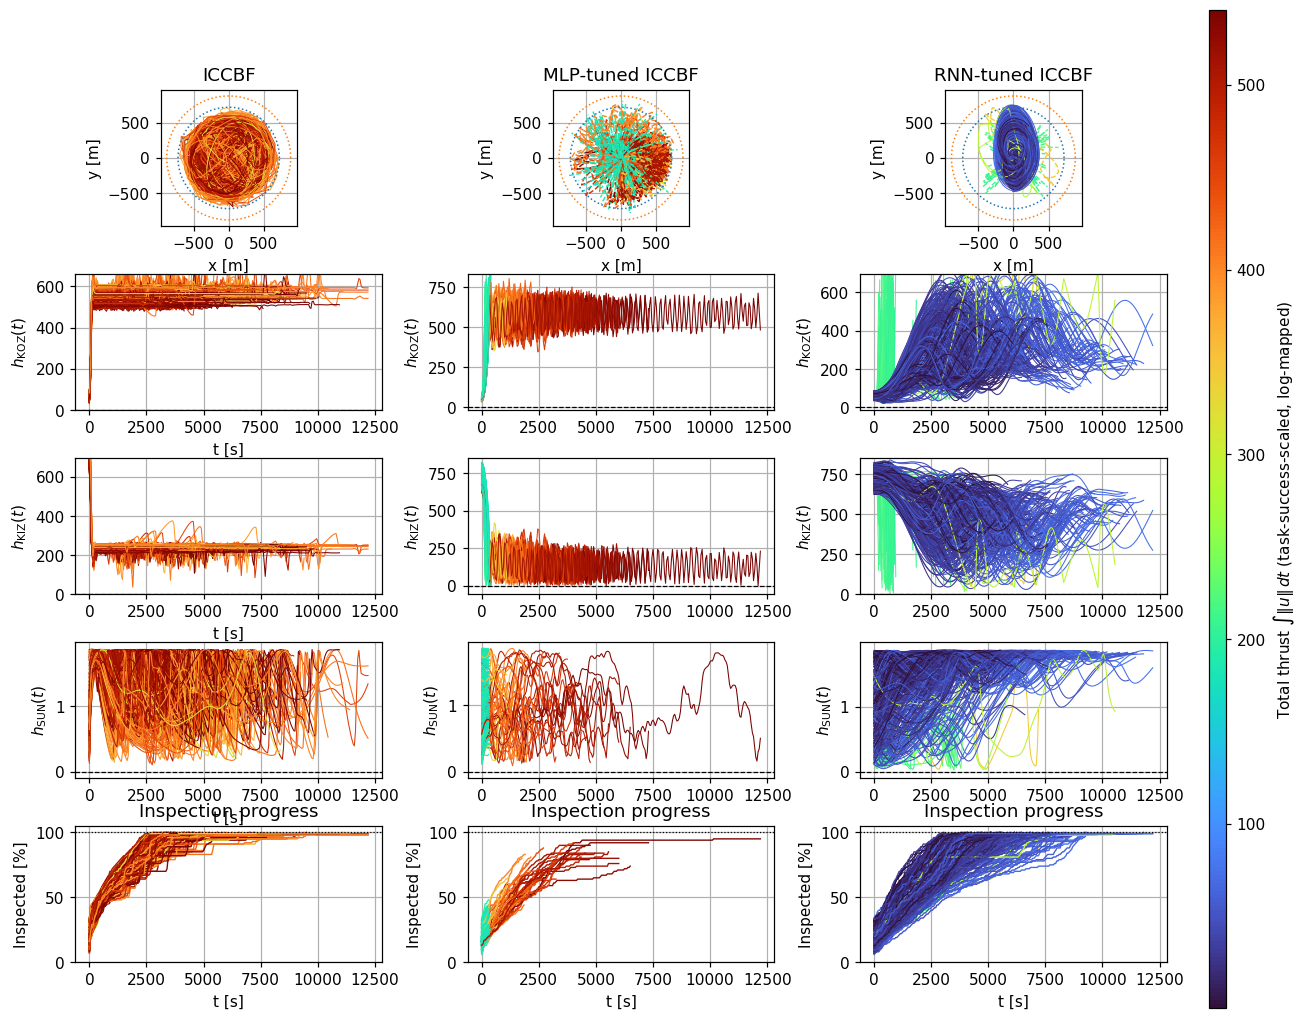

In [8]:
path_iccbf  = "../src/data/inspection/Inspection_noRL.mat"
path_stage1 = "../src/data/inspection/Inspection_MLP.mat"
path_rnn    = "../src/data/inspection/Inspection_RNNRL.mat"

from inspection.plot_inspection_results import plot_inspection_threeway

out = plot_inspection_threeway(
    baseline_mat=path_iccbf,
    mlp_mat=path_stage1,
    rnn_mat=path_rnn,
    save_prefix=None,   # or "figs/inspection_levelX"
)

print(out["latex_table"])
print("success rates:", out["success_rates"])


## DA margin Validation


To validate the accuracy of the DA interval enclosures used in the sampled-data margin computation, a MC analysis is performed along complete trajectories. For each MC episode $e$ and each discrete time step $t=kT$, the DA polynomials are re-expanded locally about the current sampled state $\mathbf{x}_{e,k}$. For the margin calculation, using DA bounding over $\mathcal{B}(\mathbf{x}_{e,k},r)$, conservative interval enclosures $[\ell_{e,k},u_{e,k}]$ are computed for
$q \in \{\, b_N,\; L_f b_N,\; \boldsymbol{L}_g b_N\},$

For each quantity \(q\), the slack at episode  $e$ and time index $k$ is defined as
\begin{equation}
s_{e,k} \;=\; \min\!\big(q_{e,k}-\ell_{e,k},\;u_{e,k}-q_{e,k}\big),
\end{equation}
where $s_{e,k}<0$ indicates a violation of the DA enclosure. To capture worst-case behavior across the MC set at each time step, the minimum slack over episodes is computed as
\begin{equation}
s_k^{\min} \;=\; \min_{e}\, s_{e,k}.
\end{equation}
The validation results are summarized using violin plots of \(\{s_k^{\min}\}_{k=1}^{K}\) for each quantity \(q\). A strictly positive violin plot indicates that the DA interval bounds remain valid across all MC trajectories and time steps under the chosen $\mathcal{B}(\mathbf{x}_{e,k},r)$, providing empirical support that the DA-derived enclosures used to construct $\widehat{l}_{(\cdot)}(\mathbf{x}_k), \widehat{\Delta} \mathbf{x}_k$, and $\widehat{\nu}(T,\mathbf{x}_k)$ are conservative along the evaluated trajectories.


<p align="center">
  <img src="images/InspDAapprox.png" alt="Distribution of distance to the computed upper and lower DA bounds for each quantity used to calculate the margin $\nu$, over all the MC episodes and all the time steps." width="100%"/>
</p>